In [1]:
import pandas as pd

In [7]:
!pip install  yfinance

In [11]:
import sys
print(sys.executable)


C:\Users\neeraj\Anaconda24\envs\analysis\python.exe


In [18]:
! "C:\\Users\\neeraj\\Anaconda24\\envs\\analysis\\python.exe" -m pip install yfinance

  Using cached yfinance-0.2.66-py2.py3-none-any.whl.metadata (6.0 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached peewee-3.18.2.tar.gz (949 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
Using cached yfinance-0.2.66-py2.py3-none-any.whl (123 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl (1.6 MB)
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15703 sha256=fd93bff4764454419df8c1a86e765d073ef9bd6ef087f57586b7d37c2e851662
  Stored in directory: c:\users\neeraj\appdat

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [9]:
import yfinance

ModuleNotFoundError: No module named 'yfinance'

In [2]:
from data_manager import fetch_data


# Fetch 1-day OHLC data for Apple
df = fetch_data("BTC-USD", "2025-08-01", "2025-10-05", period="1h")
df.columns = df.columns.get_level_values(0)
print(df.head())

C:\Users\neeraj\Analysis\data_manager.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, interval=period, progress=False)


Downloaded 1560 rows for BTC-USD from 2025-08-01 to 2025-10-04 at interval 1h
Price                              Close           High            Low  \
Datetime                                                                 
2025-08-01 00:00:00+00:00  115435.421875  115879.585938  114449.789062   
2025-08-01 01:00:00+00:00  115269.429688  115546.890625  114758.210938   
2025-08-01 02:00:00+00:00  115945.609375  115991.015625  115278.523438   
2025-08-01 03:00:00+00:00  115640.304688  116052.726562  115619.898438   
2025-08-01 04:00:00+00:00  115672.640625  115672.640625  115322.062500   

Price                               Open      Volume  
Datetime                                              
2025-08-01 00:00:00+00:00  115722.007812        <NA>  
2025-08-01 01:00:00+00:00  115401.984375  3413942272  
2025-08-01 02:00:00+00:00  115335.570312   794394624  
2025-08-01 03:00:00+00:00  115967.968750   794394624  
2025-08-01 04:00:00+00:00  115630.757812  1324482560  


C:\Users\neeraj\Analysis\data_manager.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


C:\Users\neeraj\Analysis\backtester.py:87: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.trades = pd.concat([self.trades, pd.DataFrame([{
C:\Users\neeraj\Analysis\backtester.py:328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_eq.set_xticklabels(self.data.index.strftime("%d-%b-%y")[::max(1, len(self.data)//10)],rotation=90)


Launching server at http://localhost:57814


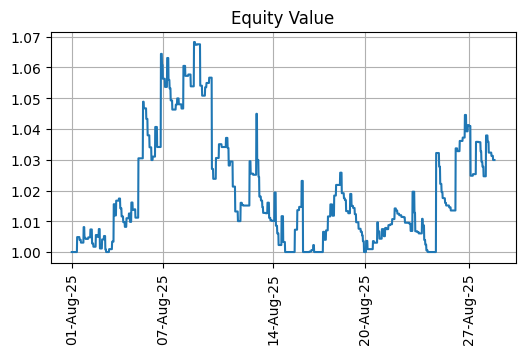

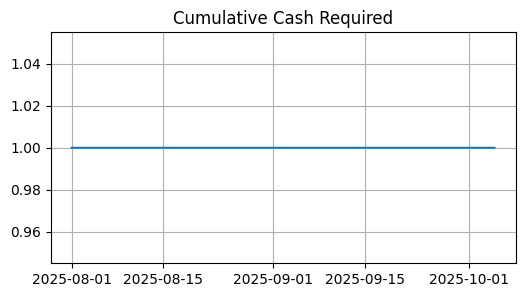

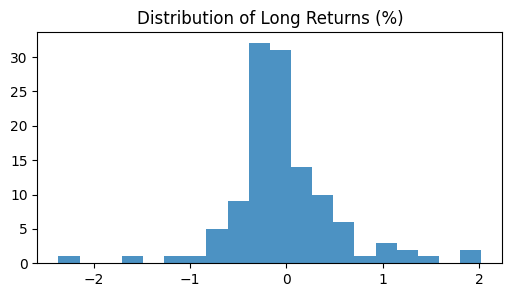

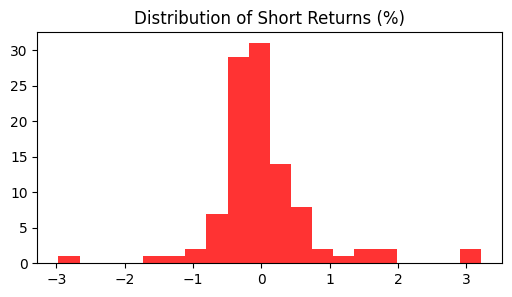

C:\Users\neeraj\Anaconda24\envs\analysis\Lib\site-packages\bokeh\util\serialization.py:242: UserWarning:

no explicit representation of timezones available for np.datetime64



In [3]:
import backtester           # import the module itself
from importlib import reload

reload(backtester)          # reload the module so your changes take effect
from backtester import BackTester   # import the class again


# Example dummy signals
def entry_long(prev, curr): 
    return curr["Close"] > prev["High"]

def exit_long(prev, curr): 
    return curr["Close"] < prev["Low"]

def entry_short(prev, curr): 
    return curr["Close"] < prev["Low"]

def exit_short(prev, curr): 
    return curr["Close"] > prev["High"]

bt = BackTester(df, slippage=10,cooling_period=2)
trades = bt.run_backtest(entry_long, exit_long, entry_short, exit_short)

#print(trades)
dashboard = bt.panel_dashboard()
dashboard.show()   # opens in browser
#print(bt.performance_summary())

In [12]:
trades.head()

,TradeID,Side,EntryIndex,ExitIndex,EntryPrice,ExitPrice,TradeReturnPct,UnderlyingPctChange
0,1,long,2025-03-03 07:45:00+00:00,2025-03-04 04:45:00+00:00,22159.800781,22044.250000,-0.521443,-0.498880
1,2,long,2025-03-04 08:45:00+00:00,2025-03-05 08:45:00+00:00,22093.550781,22321.699219,1.032647,1.055278
2,3,long,2025-03-06 07:45:00+00:00,2025-03-07 06:45:00+00:00,22471.849609,22521.300781,0.220058,0.242308
3,4,short,2025-03-10 03:45:00+00:00,2025-03-10 04:45:00+00:00,22531.650391,22636.750000,-0.466453,-0.444262
4,5,short,2025-03-10 06:45:00+00:00,2025-03-11 05:45:00+00:00,22582.449219,22457.550781,0.553077,0.575219


In [13]:
trades.drop(columns = ['EntryIndex','ExitIndex']).to_excel('trades.xlsx')

In [80]:
(22115.849609/22036.599609-1)*100


0.35962898725823145

In [83]:
((22115.849609+5)/(22036.599609-5)-1)*100


0.4050999545377687

In [82]:
1*(1+0.31417)

1.31417

<Axes: >

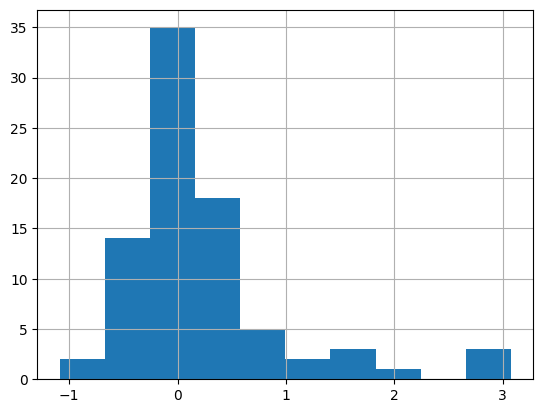

In [70]:
trades['ReturnPct'].hist()

In [71]:
df.tail(5)

Price,Close,High,Low,Open,Volume
Datetime,,,,,
2025-09-26 05:45:00+00:00,24764.300781,24780.849609,24739.949219,24769.500000,<NA>
2025-09-26 06:45:00+00:00,24758.750000,24795.300781,24753.300781,24764.400391,<NA>
2025-09-26 07:45:00+00:00,24663.550781,24760.500000,24638.449219,24759.099609,<NA>
2025-09-26 08:45:00+00:00,24644.500000,24674.650391,24629.650391,24663.949219,<NA>
2025-09-26 09:45:00+00:00,24673.099609,24674.550781,24643.599609,24644.599609,<NA>
